In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# importing csv files
seniority_df = pd.read_csv("seniority_level_december.csv")
unique_postings_df = pd.read_csv("total_uniqie_postings.csv")
unique_tites_df = pd.read_csv("unique_titles_december.csv")
postings_company_df = pd.read_csv("postings_by_company.csv")

In [3]:
seniority_df.head()

,seniority_level,postings,percentage
0,Senior,19,38.78
1,Entry-level,17,34.69
2,Mid-level,12,24.49
3,Manager,1,2.04


In [4]:
unique_postings_df.head()

,total_unique_postings
0,49


In [5]:
unique_tites_df.head()

,company,unique_title,total_postings
0,TD,32,32
1,CIBC,11,11
2,Aviva,6,6


In [6]:
postings_company_df.head(15)

,company,seniority_level,postings
0,Aviva,Entry-level,3
1,Aviva,Senior,3
2,CIBC,Manager,4
3,CIBC,Senior,3
4,CIBC,Entry-level,2
5,CIBC,Mid-level,2
6,TD,Student / Intern,17
7,TD,Senior,9
8,TD,Entry-level,4
9,TD,Manager,1


# Visual #1

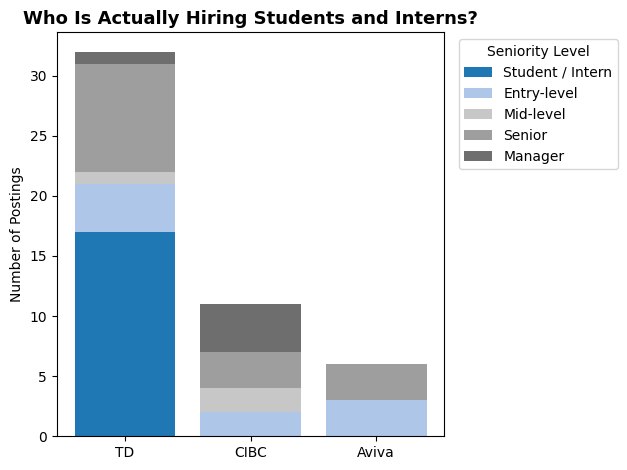

In [15]:
fig, ax = plt.subplots()

# pivot data
pivot_df = postings_company_df.pivot(
    index="company",
    columns="seniority_level",
    values="postings"
).fillna(0)

# enforcing seniority order
ordered_columns = [
    "Student / Intern",
    "Entry-level",
    "Mid-level",
    "Senior",
    "Manager"
]
pivot_df = pivot_df[ordered_columns]

# narrative company order
company_order = ["TD", "CIBC", "Aviva"]
pivot_df = pivot_df.loc[company_order]

# neutral seniority colors
colors = {
    "Student / Intern": "#1f77b4",
    "Entry-level": "#aec7e8",
    "Mid-level": "#c7c7c7",
    "Senior": "#9e9e9e",
    "Manager": "#6e6e6e"
}

# plot stacked bars
bottom = pd.Series([0] * len(pivot_df), index=pivot_df.index)

for level in pivot_df.columns:
    ax.bar(
        pivot_df.index,
        pivot_df[level],
        bottom=bottom,
        label=level,
        color=colors[level]
    )
    bottom += pivot_df[level]

# formatting
ax.set_title(
    "Who Is Actually Hiring Students and Interns?",
    fontsize=13,
    weight="bold"
)

ax.set_ylabel("Number of Postings")
ax.set_xlabel("")

ax.legend(
    title="Seniority Level",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# Visual #2

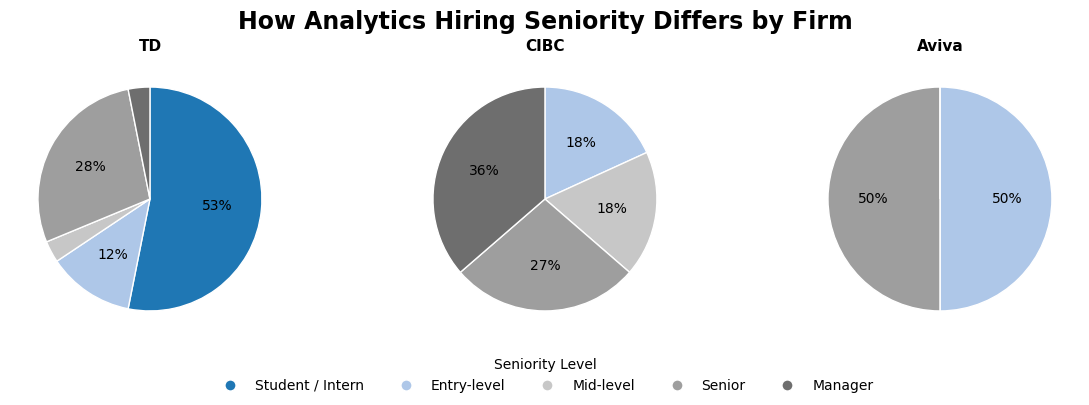

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

pivot_counts = postings_company_df.pivot(
    index="company",
    columns="seniority_level",
    values="postings"
).fillna(0)

ordered_columns = [
    "Student / Intern",
    "Entry-level",
    "Mid-level",
    "Senior",
    "Manager"
]
pivot_counts = pivot_counts[ordered_columns]

# company order
company_order = ["TD", "CIBC", "Aviva"]

# seniority colors (same as Visual 1)
colors = {
    "Student / Intern": "#1f77b4",
    "Entry-level": "#aec7e8",
    "Mid-level": "#c7c7c7",
    "Senior": "#9e9e9e",
    "Manager": "#6e6e6e"
}

# plot pies
for ax, company in zip(axes, company_order):
    values = pivot_counts.loc[company]

    ax.pie(
        values,
        labels=None,
        colors=[colors[level] for level in ordered_columns],
        autopct=lambda p: f"{p:.0f}%" if p >= 8 else "",
        startangle=90,
        counterclock=False,
        wedgeprops={"linewidth": 1, "edgecolor": "white"}
    )

    ax.set_title(company, fontsize=11, weight="bold")

# shared legend
fig.legend(
    handles=[
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=colors[level], markersize=8)
        for level in ordered_columns
    ],
    labels=ordered_columns,
    title="Seniority Level",
    loc="lower center",
    ncol=5,
    frameon=False
)

fig.suptitle(
    "How Analytics Hiring Seniority Differs by Firm",
    fontsize=17,
    weight="bold"
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()


# Visual #3

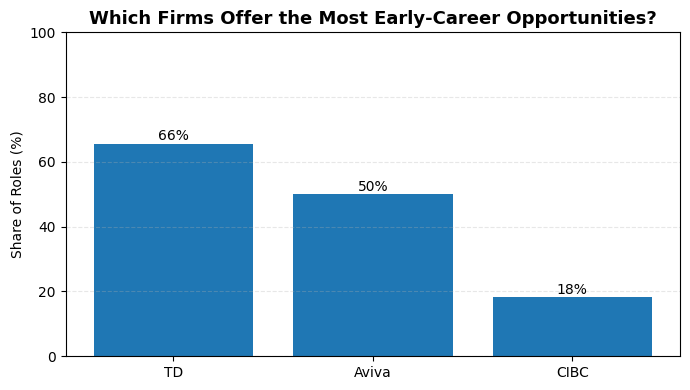

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))

# pivot counts
pivot_counts = postings_company_df.pivot(
    index="company",
    columns="seniority_level",
    values="postings"
).fillna(0)

# defining early-career roles
early_career_roles = ["Student / Intern", "Entry-level"]

# early-career percentage
early_career_pct = (
    pivot_counts[early_career_roles].sum(axis=1)
    / pivot_counts.sum(axis=1)
) * 100

# narrative order
company_order = ["TD", "Aviva", "CIBC"]
early_career_pct = early_career_pct.loc[company_order]

# plot bars
ax.bar(
    early_career_pct.index,
    early_career_pct.values,
    color="#1f77b4"
)

# annotating values
for i, value in enumerate(early_career_pct.values):
    ax.text(
        i,
        value + 1,
        f"{value:.0f}%",
        ha="center",
        fontsize=10
    )

ax.set_title(
    "Which Firms Offer the Most Early-Career Opportunities?",
    fontsize=13,
    weight="bold"
)

ax.set_ylabel("Share of Roles (%)")
ax.set_xlabel("")
ax.set_ylim(0, 100)

ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()
